**1-Import Deep Learning libraries**

In [303]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_score

from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


import matplotlib.pyplot as plt
import seaborn as sns

**2-Load Dataset**

In [304]:
df = pd.read_csv("/content/drive/MyDrive/Heart Diseases - AI Project/datasets/Processed_Datasets/stroke_clean_DL.csv")
df.head()

,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1.0,1.070138,0.0,1.0,1.0,2.777698,0.981345,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.0,1.646563,0.0,1.0,1.0,0.013842,0.459269,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,0.272012,0.0,0.0,1.0,1.484132,0.701207,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.602222,1.0,0.0,1.0,1.549193,-0.623083,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
4,1.0,1.690903,0.0,0.0,1.0,1.821368,0.013595,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


**3- Define features and target**

In [305]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

**4- Train / Validation / Test split (60/20/20)**

In [306]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

**5- SMOTE (only training set**

In [307]:
class_weight = "balanced"

class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights_values))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.5231053604436229), 1: np.float64(11.32)}


**6- Build ANN**

In [308]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**7- Compile**

In [309]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

**8-Train**

In [298]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6106 - loss: 0.6356 - val_accuracy: 0.5313 - val_loss: 0.6885
Epoch 2/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6251 - loss: 0.5541 - val_accuracy: 0.6034 - val_loss: 0.6502
Epoch 3/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6834 - loss: 0.5038 - val_accuracy: 0.6744 - val_loss: 0.5690
Epoch 4/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7201 - loss: 0.4924 - val_accuracy: 0.6967 - val_loss: 0.5245
Epoch 5/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7304 - loss: 0.4861 - val_accuracy: 0.7094 - val_loss: 0.5132
Epoch 6/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7191 - loss: 0.4853 - val_accuracy: 0.7147 - val_loss: 0.5049
Epoch 7/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7293 - loss: 0.4764 - val_accuracy: 0.7041 - val_loss: 0.5163
Epoch 8/80
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7367 - loss: 0.4563 - val_accuracy: 0.7147 - val_loss:

**9- Predict**

In [310]:
from sklearn.metrics import f1_score
import numpy as np

y_val_prob = model.predict(X_val).ravel()
y_test_prob = model.predict(X_test).ravel()


thresholds = np.arange(0.1, 0.7, 0.01)

best_threshold = 0.58
best_f1 = 0

for t in thresholds:

    y_pred = (y_val_prob > t).astype(int)

    f1 = f1_score(y_val, y_pred, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)


y_pred_test = (y_test_prob > best_threshold).astype(int)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Best Threshold: 0.5399999999999998
Best F1 Score: 0.1346153846153846


In [299]:
y_test_prob = model.predict(X_test).ravel()
y_pred_test = (y_test_prob > best_threshold).astype(int)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


**10- Evaluation**

In [300]:
cm = confusion_matrix(y_test, y_pred_test)

print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_test, zero_division=0))

print("\nF1:", f1_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test, zero_division=0))


Confusion Matrix:
 [[706 196]
 [ 15  27]]

Classification Report:

              precision    recall  f1-score   support

         0.0       0.98      0.78      0.87       902
         1.0       0.12      0.64      0.20        42

    accuracy                           0.78       944
   macro avg       0.55      0.71      0.54       944
weighted avg       0.94      0.78      0.84       944


F1: 0.2037735849056604
Recall: 0.6428571428571429
Precision: 0.1210762331838565


**11- Confusion Matrix Plot**

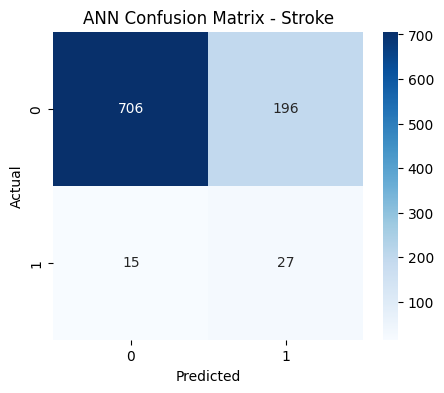

In [301]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("ANN Confusion Matrix - Stroke")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**12- Training Curve**


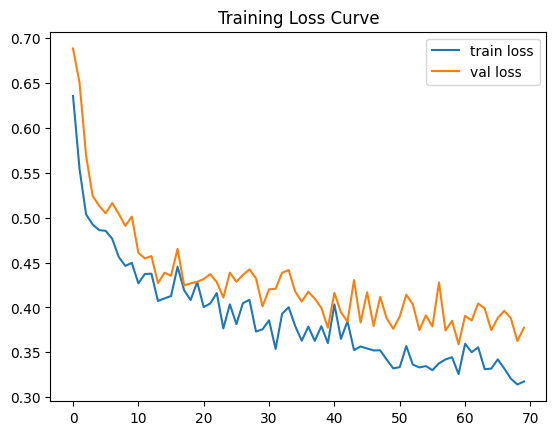

In [302]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Training Loss Curve")
plt.show()